# Sea Level Anomaly, Thermocline Depth, and Kelvin Waves in the Equatorial Pacific

This notebook uses satellite altimetry (Copernicus SLA), sea surface temperature (NOAA OISST), zonal wind (CCMP), and subsurface temperature (Roemmich–Gilson Argo climatology) to visualize equatorial Kelvin wave propagation and the subsurface signature of the 2015–2016 El Niño event.

This notebook uses the Argovis web app and database. Argovis provides an API that indexes and distributes numerous oceanographic datasets with detailed query parameters, enabling you to search and download only and exactly the data of interest.

**How to cite:** If you use this notebook, please cite Sala, J., Giglio, D., Mills, K., & Scanderbeg, M. (2026). *argovis/demo_notebooks* (v0.1.0) [Software]. Zenodo. [https://doi.org/10.5281/zenodo.22032966](https://doi.org/10.5281/zenodo.22032966)

## Learning Goals

By the end of this activity, you will be able to:

1. **Build Hovmöller diagrams** of zonal wind, SST, SLA, and thermocline depth (D20) anomalies — and identify eastward-propagating Kelvin waves in the Equatorial Pacific.
2. **Compute the Niño 3.4 ENSO index** from OISST and classify El Niño / La Niña periods.
3. **Examine longitude–depth temperature sections** at key snapshots before, during, and after the 2015–2016 El Niño event and interpret the subsurface thermal signature.
4. **Connect surface and subsurface signals** — link wind forcing, sea level anomalies, thermocline depth changes, and SST to the full picture of ENSO dynamics.

## Setup: register an API key

In order to allocate Argovis's limited computing resources fairly, users are encouraged to register and request a free API key. This works like a password that identifies your requests to Argovis.

1. Visit [https://argovis-keygen.colorado.edu/](https://argovis-keygen.colorado.edu/)
2. Fill out the form under **New Account Registration**
3. An API key will be emailed to you shortly

Treat your API key like a password — don't share it or leave it anywhere public. If you ever forget it or accidentally reveal it, visit the same website to change or deactivate your token.

Set `APIKEY` in the cell below before running anything else. The notebook may still work with `'guest'` but may return errors under heavy load.

## Setup: import libraries and functions

The cells below import all required scientific libraries and the notebook helper functions from `notebook_helpers/`. Run them in order before anything else.

In [1]:
# ── Imports — run this cell first, do not modify ───────────────────────────
from argovisHelpers import helpers as avh
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

APIKEY  = 'guest'  # Put your API key here
APIROOT = 'https://argovis-api.colorado.edu/'

## Setup: import helper functions

The functions below are used throughout the notebook. You do not need to edit them.
- `traverse_query` — loop over all region × time × dataset combinations and call the Argovis API. Returns gridded fields (one per dataset), not individual profiles.
- `tidy_grid` — sorts every spatial/temporal dimension of a gridded field so it's monotonic-increasing, and un-wraps longitude for boxes that cross the antimeridian. Needed because the API can return coordinates out of order, and a box crossing 180° comes back split into a negative and a positive branch — without this, `.sel(slice(...))`, `.interp`, and `contourf` can silently misbehave or show a broken/discontinuous longitude axis.
- `spatial_average` — *input: a gridded field.* Cos-latitude-weighted mean over a latitude band. `lat_band` is the actual `(lat_min, lat_max)` range of values to average over; `lat_dim` is just the *name* of the latitude coordinate in `da` (default `'latitude'`) — it lets the function work even if a dataset happens to label that coordinate differently, and is unrelated to the range itself. `lon_dim` plays the same "coordinate name" role for longitude (default `None`, meaning don't touch longitude). Only a latitude *range* can be specified — there is no equivalent `lon_band` argument. If `lon_dim` is provided, longitude is also fully collapsed to a scalar time series; otherwise longitude is left at its full queried resolution and only latitude is collapsed (Hovmöller output) — it does not average over longitude in that case.
- `remove_seasonal_cycle` — subtract the monthly climatology from a time series (or gridded time × space field) to produce an anomaly, keeping the trend; optionally smoothed with a centred running-mean via `smooth_window`
- `find_isotherm_depth` — depth (in the input's native level units, e.g. dbar) of the `iso`-degree isotherm, by linear interpolation between the two bracketing levels
- `plot_hovmoller` — *input: gridded (time × longitude) fields.* 4-panel Hovmöller diagram (wind, SST, SLA, D20) with an ENSO state stripe
- `plot_temperature_sections` — *input: a gridded (time × level × longitude) field.* Stacked longitude–depth temperature sections with the 20°C isotherm

In [2]:
# ── Helper functions — run, do not modify ──────────────────────────────────
from notebook_helpers.functions import traverse_query
from notebook_helpers.functions_candidates_for_functions import remove_seasonal_cycle, spatial_average
from notebook_helpers.functions_SLA import (
    plot_hovmoller,
    plot_temperature_sections,
    tidy_grid,
    find_isotherm_depth
)

## Setup: configuration

✏️ **Student Work — Configuration**

Define your region, time period, datasets, and latitude band here. All downstream cells read from these variables.

This notebook handles exactly **one region and one time period per run** — provide exactly one of each. `traverse_query` (the function that downloads the data) is written generically to accept a *list* of regions and a *list* of time periods, so it can loop over every region × time × dataset combination — but every cell below always reads only the first entry of the output list from `traverse_query` (`grid_results[...][0][0]`). If you list more than one region or time period, `traverse_query` will still dutifully query all of them (costing real time), but everything after the first would be silently ignored by the rest of the notebook. That's why the cell below builds `regions = [region]` and `time_periods = [time_period]` from single `region`/`time_period` variables — to satisfy what `traverse_query` expects while keeping it clear that only one of each is actually used.

Key parameters to explore:
- **`region`**: bounding box for the equatorial Pacific query
- **`time_period`**: start/end date pair — try different ENSO periods within the queried window (e.g. the 2015–2016 El Niño). The 1997–1998 El Niño is also of interest, but note the RG09 Argo climatology only starts around 2004, so the D20/thermocline panel would be empty if you go back that far.
- **`grids`**: gridded collections and variables to retrieve (wind, SLA, SST, RG09 temperature)
- **`ENSO_LAT_BAND`**: latitude band used for all spatial averages — computed directly from `region`'s box latitude limits (see the comment in the cell below), so it can't drift out of sync with the box even if you change it


In [3]:
# MODIFY HERE — exactly one region, one time period (see note above)
#
# Alternative regions — uncomment ONE line to replace `region` below. Timings are all
# full 2010-2017, 4-dataset runs, but this API has high run-to-run variance (seen up to
# ~2x on the exact same box in testing) -- treat these as rough orientation, not guarantees.
# region = {'box': [[120, -1], [180, 1]]}      # Western Pacific
# region = {'box': [[-180, -1], [-70, 1]]}     # Eastern Pacific
# region = {'box': [[-240, -2], [-80, 2]]}     # full basin, +-2 deg lat -- ~19 min
# region = {'box': [[-240, -1], [-80, 1]]}     # full basin, +-1 deg lat -- ~11 min
# region = {'box': [[-220, -1], [-90, 1]]}     # narrower, +-1 deg lat -- ~8-12 min
# region = {'box': [[-225, -0.5], [-120, 0.5]]} # 135E-120W, +-0.5 deg lat -- ~4.5 min;
#                                                # narrower lat did NOT meaningfully help
#                                                # vs +-1 deg at the same longitude width
# region = {'box': [[-200, -1], [-100, 1]]}    # narrower, +-1 deg lat -- ~5 min

region = {'box': [[-225, -1], [-120, 1]]}      # 135E-120W, +-1 deg lat -- ~4 min, and starts
                                                # further west (135E) to reliably catch
                                                # westerly-wind-burst origins

# traverse_query expects a list of regions; this notebook only ever uses regions[0]
regions = [region]

# ── Latitude bands ────────────────────────────────────────────────────────────
# Derived directly from region's box (box = [[lon_min, lat_min], [lon_max, lat_max]])
# rather than set separately, so it can never go out of sync with the box above.
ENSO_LAT_BAND = (region['box'][0][1], region['box'][1][1])

time_period = {'startDate': '2010-01-01T00:00:00Z', 'endDate': '2017-01-01T00:00:00Z'}

# traverse_query expects a list of time periods; this notebook only ever uses time_periods[0]
time_periods = [time_period]

# ── Collections & variables ───────────────────────────────────────────────────
grids = {
    'timeseries/copernicussla': 'sla',
    'timeseries/noaasst':       'sst',
    'timeseries/ccmpwind':      'uwnd',
    'grids/rg09':               'rg09_temperature',
    # 'grids/localGPintegral':  'potential_temperature',
}

from numpy import timedelta64
span = (np.datetime64(time_period['endDate'][:10]) - np.datetime64(time_period['startDate'][:10]))
if span < timedelta64(365*3, 'D'):
    print('Time period < 3 years: the monthly climatology will be poorly sampled '
          'and the seasonal-cycle removal will alias ENSO. Consider a longer span.')

## Step 1 — Query gridded products from the Argovis API

The cell below downloads zonal wind, SLA, SST, and RG09 temperature for all region × time combinations. Depending on the time range, this may take a few minutes.

In [4]:
# ── Step 1: Query gridded products — run, do not modify ────────────────────
grid_results = traverse_query(regions, time_periods, grids, avh.queryGrid, APIKEY, APIROOT)

## Step 2 — Pre-process all variables

Each block below applies `spatial_average` and `remove_seasonal_cycle` to produce the deseasonalized anomaly fields used in the figures. All variables use the same latitude band (`ENSO_LAT_BAND`). In this notebook we do not show plots of the seasonal cycle.

| Variable | Dataset | Output |
|---|---|---|
| Zonal wind (uwnd) | CCMP | `wind_anom` |
| SST / ENSO index | NOAA OISST | `sst_anom_hov`, `enso_index` |
| Sea level anomaly | Copernicus | `sla_anom` |
| Thermocline depth (D20) | RG09 Argo | `d20_anom` |

In [5]:
# ── Wind pre-processing — run, do not modify ─────────────────────────────
# Uses the CCMP zonal (east-west) wind component uwnd, not wind speed ws — ws is a
# scalar magnitude that can't distinguish a westerly burst from a stronger easterly.
# CCMP has no wind-stress variable, so uwnd is the closest available proxy: positive
# = eastward/westerly, which is the sign that triggers downwelling Kelvin waves.
wind_raw     = grid_results['timeseries/ccmpwind'][0][0].uwnd
wind         = wind_raw.squeeze('level') if 'level' in wind_raw.dims else wind_raw
wind         = tidy_grid(wind)
wind_equator = spatial_average(wind, ENSO_LAT_BAND)
wind_anom    = remove_seasonal_cycle(wind_equator)

print('Wind Hovmöller computed successfully.')

Wind Hovmöller computed successfully.


In [6]:
# ── SST pre-processing: ENSO index + SST anomaly Hovmöller — run, do not modify ──
# Niño 3.4 region: 1°S–1°N (ENSO_LAT_BAND), 170°W–120°W = 190°E–240°E after tidy_grid's
# antimeridian unwrap. Used for the ENSO index only — the Hovmöller panel below uses
# the full queried longitude range, like wind/SLA/D20.
sst_raw = grid_results['timeseries/noaasst'][0][0].sst
sst_raw = sst_raw.squeeze('level') if 'level' in sst_raw.dims else sst_raw
sst     = tidy_grid(sst_raw)

sst_nino34 = sst.sel(latitude=slice(*ENSO_LAT_BAND), longitude=slice(190, 240))

# ENSO index: area-weighted mean (lat+lon) → deseasonalize → 13-step running mean
sst_mean   = spatial_average(sst_nino34, ENSO_LAT_BAND, lon_dim='longitude')
enso_index = remove_seasonal_cycle(sst_mean, smooth_window=13)

# SST anomaly Hovmöller: latitude-average only, full longitude range → deseasonalize
sst_lat_mean = spatial_average(sst, ENSO_LAT_BAND).squeeze()
sst_anom_hov = remove_seasonal_cycle(sst_lat_mean)

print('SST / ENSO index computed successfully.')

SST / ENSO index computed successfully.


In [7]:
# ── SLA pre-processing — run, do not modify ──────────────────────────────────
sla_raw     = grid_results['timeseries/copernicussla'][0][0].sla
sla_raw     = sla_raw.squeeze('level') if 'level' in sla_raw.dims else sla_raw
sla         = tidy_grid(sla_raw)
sla_equator = spatial_average(sla, ENSO_LAT_BAND)
sla_anom    = remove_seasonal_cycle(sla_equator)

print('SLA Hovmöller computed successfully.')

SLA Hovmöller computed successfully.


In [8]:
# ── RG09 temperature pre-processing — run, do not modify ──────────────────────
temp = tidy_grid(grid_results['grids/rg09'][0][0].rg09_temperature)

# D20: latitude-average over the equatorial band, then isotherm depth by
# bracket interpolation (mirrors Katie's MLD approach — no fine pre-interp).
temp_eq_mean = spatial_average(temp, ENSO_LAT_BAND)        # time × level × longitude
d20          = find_isotherm_depth(temp_eq_mean, iso=20.0)  # time × longitude
d20_anom     = remove_seasonal_cycle(d20)

# Vertical sections: same band, latitude-averaged, levels kept (time × level × longitude)
temp_eq = temp.sel(latitude=slice(*ENSO_LAT_BAND)).mean(dim='latitude')

print('RG09 Hovmöller computed successfully.')

RG09 Hovmöller computed successfully.


## SST and Niño 3.4 ENSO index

Sea surface temperature (SST) from the NOAA OISST product is used to compute the
[Niño 3.4 index](https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni),
a standard measure of ENSO state. The index is the area-weighted SST anomaly averaged
over 1°S–1°N, 170°W–120°W, smoothed with a 13-week running mean.

A value ≥ +0.5°C sustained for five consecutive overlapping 3-month periods defines **El Niño**;
≤ −0.5°C defines **La Niña**.

[Real-time ENSO index — NOAA NCEI](https://www.ncei.noaa.gov/access/monitoring/enso/sst)

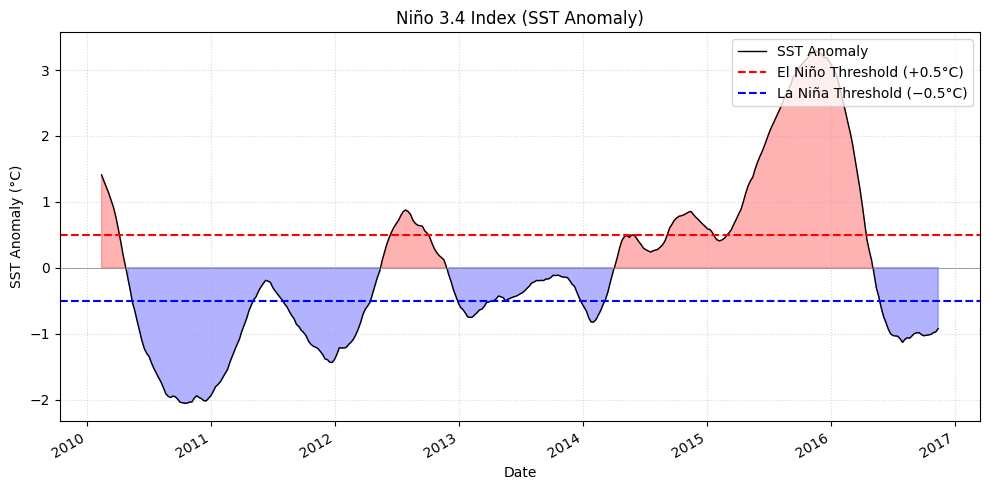

In [9]:
# ── Plot the Niño 3.4 ENSO index — run, do not modify ────────────────────────
plt.figure(figsize=(10, 5))
enso_index.plot(color='black', linewidth=1, label='SST Anomaly')
plt.axhline(0,    color='gray',  linewidth=0.5)
plt.axhline( 0.5, color='red',   linestyle='--', label='El Niño Threshold (+0.5°C)')
plt.axhline(-0.5, color='blue',  linestyle='--', label='La Niña Threshold (−0.5°C)')
plt.fill_between(enso_index.timestamp, 0, enso_index, where=(enso_index >= 0), color='red',  alpha=0.3)
plt.fill_between(enso_index.timestamp, 0, enso_index, where=(enso_index < 0),  color='blue', alpha=0.3)
plt.title('Niño 3.4 Index (SST Anomaly)')
plt.ylabel('SST Anomaly (°C)'); plt.xlabel('Date')
plt.legend(loc='upper right'); plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout(); plt.show()

## Combined Hovmöller diagram

This figure summarises the equatorial Pacific state across four Hovmöller plots that share a common vertical axis indicating time (most recent year at the top). A narrow colored stripe on the left edge of each panel encodes information about the ENSO index: red for Niño 3.4 index ≥ +0.5°C, blue for Niño 3.4 index ≤ −0.5°C, and gray otherwise. Note this is a per-timestep threshold on the index alone — calling a period El Niño or La Niña additionally requires the index to stay past that threshold for five consecutive overlapping 3-month periods (see the Niño 3.4 section above), which this stripe does not check.

**Panel 1 — Zonal wind anomaly (Hovmöller).**
Deseasonalized CCMP zonal wind (uwnd), averaged over 1°S–1°N. Positive (eastward/westerly) anomalies in the western Pacific are a key trigger for downwelling Kelvin waves and El Niño onset.

**Panel 2 — SST anomaly (Hovmöller).**
Deseasonalized sea surface temperature from NOAA OISST, averaged over 1°S–1°N. Dashed contours mark the ±0.5°C threshold. During the 2015–2016 El Niño, positive SST anomalies emerge across nearly the entire plotted longitude range.

**Panel 3 — SLA anomaly (Hovmöller).**
Deseasonalized sea level anomaly from the Copernicus satellite altimetry product, averaged over 1°S–1°N. Positive SLA (red) reflects thermocline deepening and warm water accumulation; negative SLA (blue) reflects the opposite. Equatorial Kelvin waves appear as eastward-propagating diagonal features.

**Panel 4 — D20 anomaly (Hovmöller).**
Anomalous pressure on the 20°C isotherm from the Roemmich–Gilson Argo climatology (RG09), averaged over 1°S–1°N. D20 is defined using pressure — not metres, since pressure is the vertical dimension in the RG09 product — but is a direct proxy for thermocline depth. Positive anomalies (red) indicate a deeper-than-normal thermocline; negative anomalies (blue) indicate shoaling. Black contours every 20 dbar; the bold line marks zero.


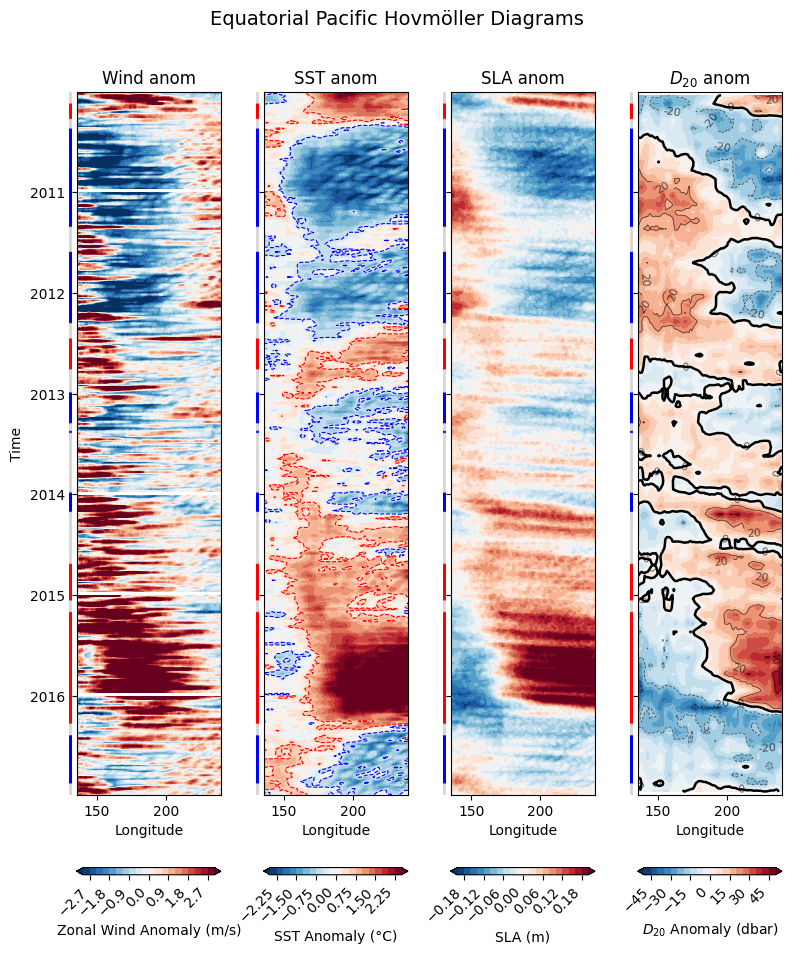

In [10]:
# ── Hovmöller diagram — run, do not modify ─────────────────────────────────
plot_hovmoller(wind_anom, sst_anom_hov, sla_anom, d20_anom, enso_index=enso_index)


---
**Compare your results with:**

Hu, S., and Fedorov, A. V. (2017). The extreme El Niño of 2015–2016: the role of westerly and easterly wind bursts, and preconditioning by the failed 2014 event. *Climate Dynamics*, 50, 4055–4660. https://doi.org/10.1007/s00382-017-3531-2

## ✏️ Student Work — Question 1: Kelvin Wave Propagation

Study the four Hovmöller panels above.

1. Do you see diagonal features propagating eastward in the **SLA** and **D20** panels? Describe their direction.
2. Look at the **Wind** panel: do westerly wind bursts in the western Pacific (left side) appear to precede positive SLA and D20 anomalies propagating eastward? What does this suggest about the forcing mechanism?
3. How do the surface signals (SST, SLA) compare to the subsurface signal (D20) — are they in phase, or is there a lag?

*Double-click to edit this cell and write your answer.*

## Vertical temperature sections + 20°C isotherm

✏️ **Student Work — Questions about ENSO phases**

In the following, we will connect longitude–depth snapshots to different ENSO phases. Four snapshots are plotted below, covering one neutral period, one El Niño peak, and two La Niña peaks. Their panel titles are intentionally generic (`Snapshot A`, `Snapshot B`, ...) — Question 1 below asks you to work out which ENSO phase each one is from, using the Hovmöller diagrams above and the black 20°C isotherm contour on each panel.

The black contour marks the 20°C isotherm (D20, in pressure/dbar). Its deepening in the central and eastern Pacific is the defining subsurface signature of a developing El Niño; its subsequent shoaling marks the transition back toward La Niña.

In [11]:
# MODIFY HERE — labels intentionally do not reveal the ENSO phase (see Question 1 below)
dates_to_compare = {
    'Snapshot A': '2013-07-15',
    'Snapshot B': '2015-11-15',
    'Snapshot C': '2011-01-15',
    'Snapshot D': '2011-10-15',
}

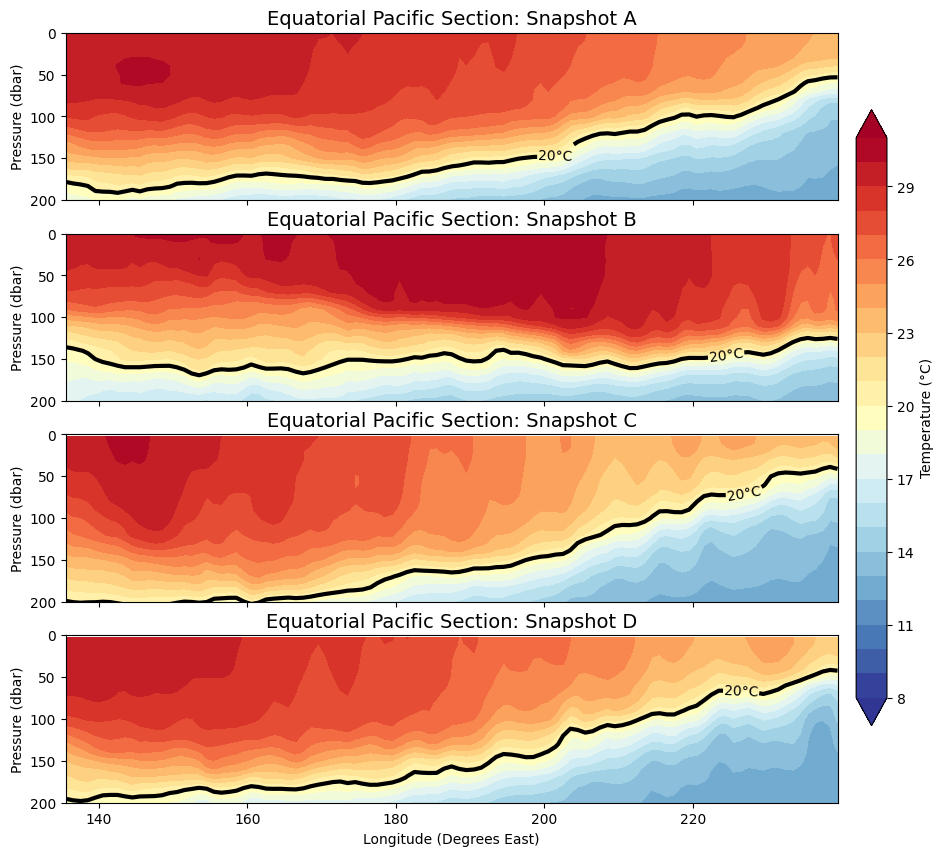

In [12]:
# ── Vertical temperature sections — run, do not modify ─────────────────────
plot_temperature_sections(temp_eq, dates_to_compare)

## ✏️ Student Work — Question 2: ENSO Phases in the Temperature Sections

Study the vertical temperature sections above.

1. For each of the four panels above (the panel titles intentionally don't reveal the phase), indicate what ENSO phase — neutral, El Niño, or La Niña — it is from, and how you reached that conclusion.
2. Compare the pressure of the 20°C isotherm (black contour) across your snapshots. In which snapshot is the thermocline deepest in the central/eastern Pacific? In which is it shallowest in the western Pacific?
3. During the El Niño peak, how does the temperature structure in the **eastern Pacific** and in the **western Pacific** each differ from the neutral period? Does the warm water extend deeper or shallower in each region?
4. How do the subsurface changes you see here connect to the surface signals (SST and SLA anomalies) you observed in the Hovmöller diagrams?

*Double-click to edit this cell and write your answer.*

---
**⚠️ INSTRUCTOR ANSWER KEY — remove or hide this cell before sharing with students**

Based on the dates currently set in `dates_to_compare` above:
- **Snapshot A** (2013-07-15): Neutral
- **Snapshot B** (2015-11-15): El Niño peak
- **Snapshot C** (2011-01-15): La Niña peak
- **Snapshot D** (2011-10-15): La Niña peak (secondary dip of the 2011–2012 La Niña)

If you change the dates in the cell above, update this key accordingly.

### References

- **Hu, S., and Fedorov, A. V. (2017)** — The extreme El Niño of 2015–2016: the role of westerly and easterly wind bursts, and preconditioning by the failed 2014 event. *Climate Dynamics*, 50, 4055–4660. https://doi.org/10.1007/s00382-017-3531-2